**Problem 5**: Now that we can derive relatively accurate models, the next thing to do is to analyse the behaviour of systems under a control input. How can we understand and tune parameters for desirable behaviour?

Consider a motor with the transfer function:
$$ P(s) = \dfrac{K}{\tau s + 1}$$
First, we will see how the system naturally behaves. We already know that the DC gain is $P(0) = K$, and the time constant is $\tau$. This means that the system takes $\tau$ units of time, in this case let's use seconds, to settle. 

Now let's analyse this. We know that $s = \sigma + j \omega$, which is a variable in the complex plane. Giving it an arbitrary voltage signal yields:
$$ \Omega(s) = \dfrac{K V(s)}{\tau s + 1}$$
Rewriting it as
$$ \Omega(s) = \dfrac{K}{\tau} . \dfrac{1}{s + \frac{1}{\tau}} V(s)$$
we can now take the inverse Laplace transform. Recall that the convolution theorem states that:
$$\mathcal{L}^{-1}(FG) = f * g$$
Therefore:
$$ \omega(t) = \dfrac{K}{\tau} e^{-\frac{t}{\tau}} * v(t) = \dfrac{K}{\tau} \int_0^t e^{-\frac{t - \lambda}{\tau}}v(\lambda)d\lambda$$
Now comes the fun part. Look back to the transfer function for a moment. We define a pole to be the asymptote of the function in the 3D space, and in this case, we have the pole $s = -\frac{1}{\tau}$. Looking agains at the function for angular velocity, we can see:
$$ \omega (t) = \dfrac{K}{\tau}e^{st} \int_0^t e^\frac{-\lambda}{\tau}v(\lambda)d\lambda$$
What this means, is that: for every voltage signal possible, the behaviour of the output motion is governed only by the exponential $e^{st}$. By analysing the poles of the system, we can determine its behaviour. 

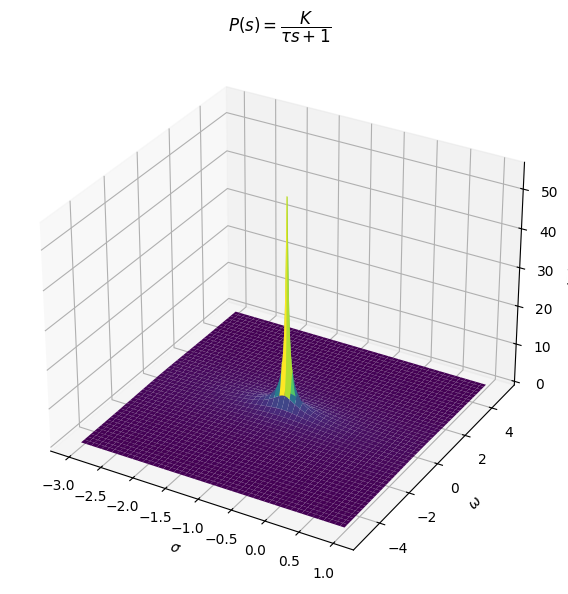

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Parameters
K = 1.0
tau = 1.0

# Create complex s-plane
sigma = np.linspace(-3, 1, 300)
omega = np.linspace(-5, 5, 300)

Sigma, Omega = np.meshgrid(sigma, omega)
S = Sigma + 1j * Omega

# Transfer function
P = K / (tau * S + 1)

# Magnitude
Z = np.abs(P)

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    Sigma,
    Omega,
    Z,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
)

ax.set_xlabel(r"$\sigma$")
ax.set_ylabel(r"$\omega$")
ax.set_zlabel(r"$|P(s)|$")
ax.set_title(r"$P(s)=\dfrac{K}{\tau s+1}$")

plt.show()

We are going to control it with a feedback P controller. For a negative feedback system, the transfer function is given by:
$$ G(s) = \dfrac{G_1(s)G_2(s)}{1 - G_1(s)G_2(s)}$$
Our controller would be a simple $u(t)$ = $K_p e$. Then:
$$ U(s) = K_p E(s) \Rightarrow G_c(s) = \dfrac{U(s)}{E(s)} = K_p $$